## **The Changing Cost of Homeownership in the U.S**

### **Team Name: Stat Squad**
Members: Emily Aguilar (emilyo2), Yasmine Chatila (ychati2), Zahabiya Lokhandwala (zlokh2), Tasneem Mubashshira (tmubas2), Angel Corral-Esparza (acorr24) <br>
Github: https://github.com/uic-cs418/group=project-stat-squad.git

## **1. Introduction:**
This project analyzes the growing gap between median income and home prices across U.S. states from 2000 to 2023. Using yearly income data and aggregated home value data, we compared trends to understand **why homeownership is becoming less affordable day by day.**. Our main hypothesis is that housing prices are outpacing income growth which is the causing less affordibility even if the income rises. <br>
To explore this, we developed a series of visualizations to illustrate national and state-level trends. In addition, we applied two machine learning techniques to deepen our analysis: K-Means clustering to group states by affordability levels based on income and housing trends, and regression modeling to assess how well income-related factors can predict home values. These methods revealed useful patterns—showing which states are still affordable and suggesting that other factors beyond income may be driving the rise in home prices.

## **2. Data Cleaning:**
**Zillow Home Values Dataset:** (https://www.zillow.com/research/data/) <br>The zillow dataset contains monthly median home values from January 2000 to 2025 for 895 U.S. regions, with each row representing a region and each column (from the 6th onward) representing a specific month. The dataset has a high temporal granularity (monthly) and a wide spatial scope, covering diverse regions across the U.S. The timestamps were originally in string format and were converted to datetime objects for accurate time-based analysis. We found significant missing data. We removed the rows with more than 40% missing data. For the remaining missing values, we applied linear interpolation across time (columns), followed by forward and backward fill to handle edge cases. All numeric values were explicitly converted to float to ensure consistency and compatibility with analysis tools.

**FRED Median Household Income Dataset:** (https://fred.stlouisfed.org/release/tables?rid=249&eid=259515&od=#) <br> The income dataset contains annual median household income for each U.S. state from 2000 to 2023. The income values included commas (e.g., "$75,000"), which were removed, and all values were converted to numeric types. To enable merging with the home values dataset, a new column for state codes (e.g., "IL" for Illinois) was added using a standard name-to-code mapping. Both datasets were aligned on state codes for consistency in comparative analysis. No missing values were found in the income data, so no imputation was necessary.

**Income By Location:**  (https://datausa.io/profile/geo/illinois?genderUniversities=sex2&propertyTaxesValue=propertyTaxes&rentMortgage=homeownersMortgage#housing) <br>This data set contains median income in 2023 for Illinois residents. Each column contains the year, Geography, Household Income by Race, Household Income by Race MOE. Each row represents a county in Illinois (2023 information only). In our investigation we did not focus on race as a factor and cleaned the data to include 'Total' or overall household incomes for each county.  

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import all_functions

In [3]:
home_values_dataset = pd.read_csv('homevalue.csv')
income = pd.read_csv('median_income.csv')
home_values = all_functions.cleaning_homevalues(home_values_dataset)

In [4]:
merged = all_functions.CreateMerged(home_values_dataset,income)

merged() function adds state abbreviations and cleans the datasets by changing the format to long. It then merges the home_value and income datasets 
and calulates the price to income ratio by dividing the median house price by the median inome in each state for each year. 
Then presents the data in a heatmap showcasing affordability in each state.

## **3. Visualizations**

### **Visualization 1 : Diverging Trends: U.S. National Median Income vs. Home Value (2000–2023)**
**Hypothesis 1**:  Median household income in the United States has not increased at the same rate as median home values, making it increasingly difficult for people to afford buying a home.

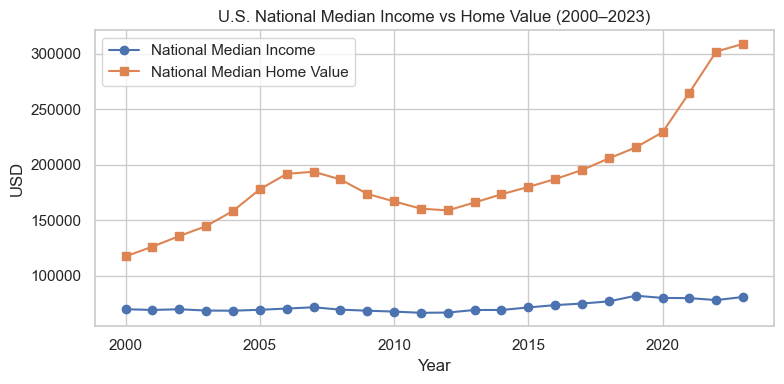

In [17]:
all_functions.visual1(merged)

#### **Why Homeownership is Slipping Away: U.S. Income vs Housing Costs (2000–2023)**
The following line chart compares the national median income and national median home value in the United States from 2000 to 2023. While median income has increased only modestly over the two decades, home values have risen sharply—especially after 2020. This divergence indicates a growing affordability gap, where home prices are increasing faster than people's ability to pay for them. This trend helps explain why first-time homeownership has become increasingly out of reach for many Americans.

But this raises an important question: **Is earning more enough to afford a home in today’s market?**

### **Visualization 2: Ideal Home Values vs Real Home Values**
**Hypothesis 2:** Increased income does not ensure the ability to purchase a home.

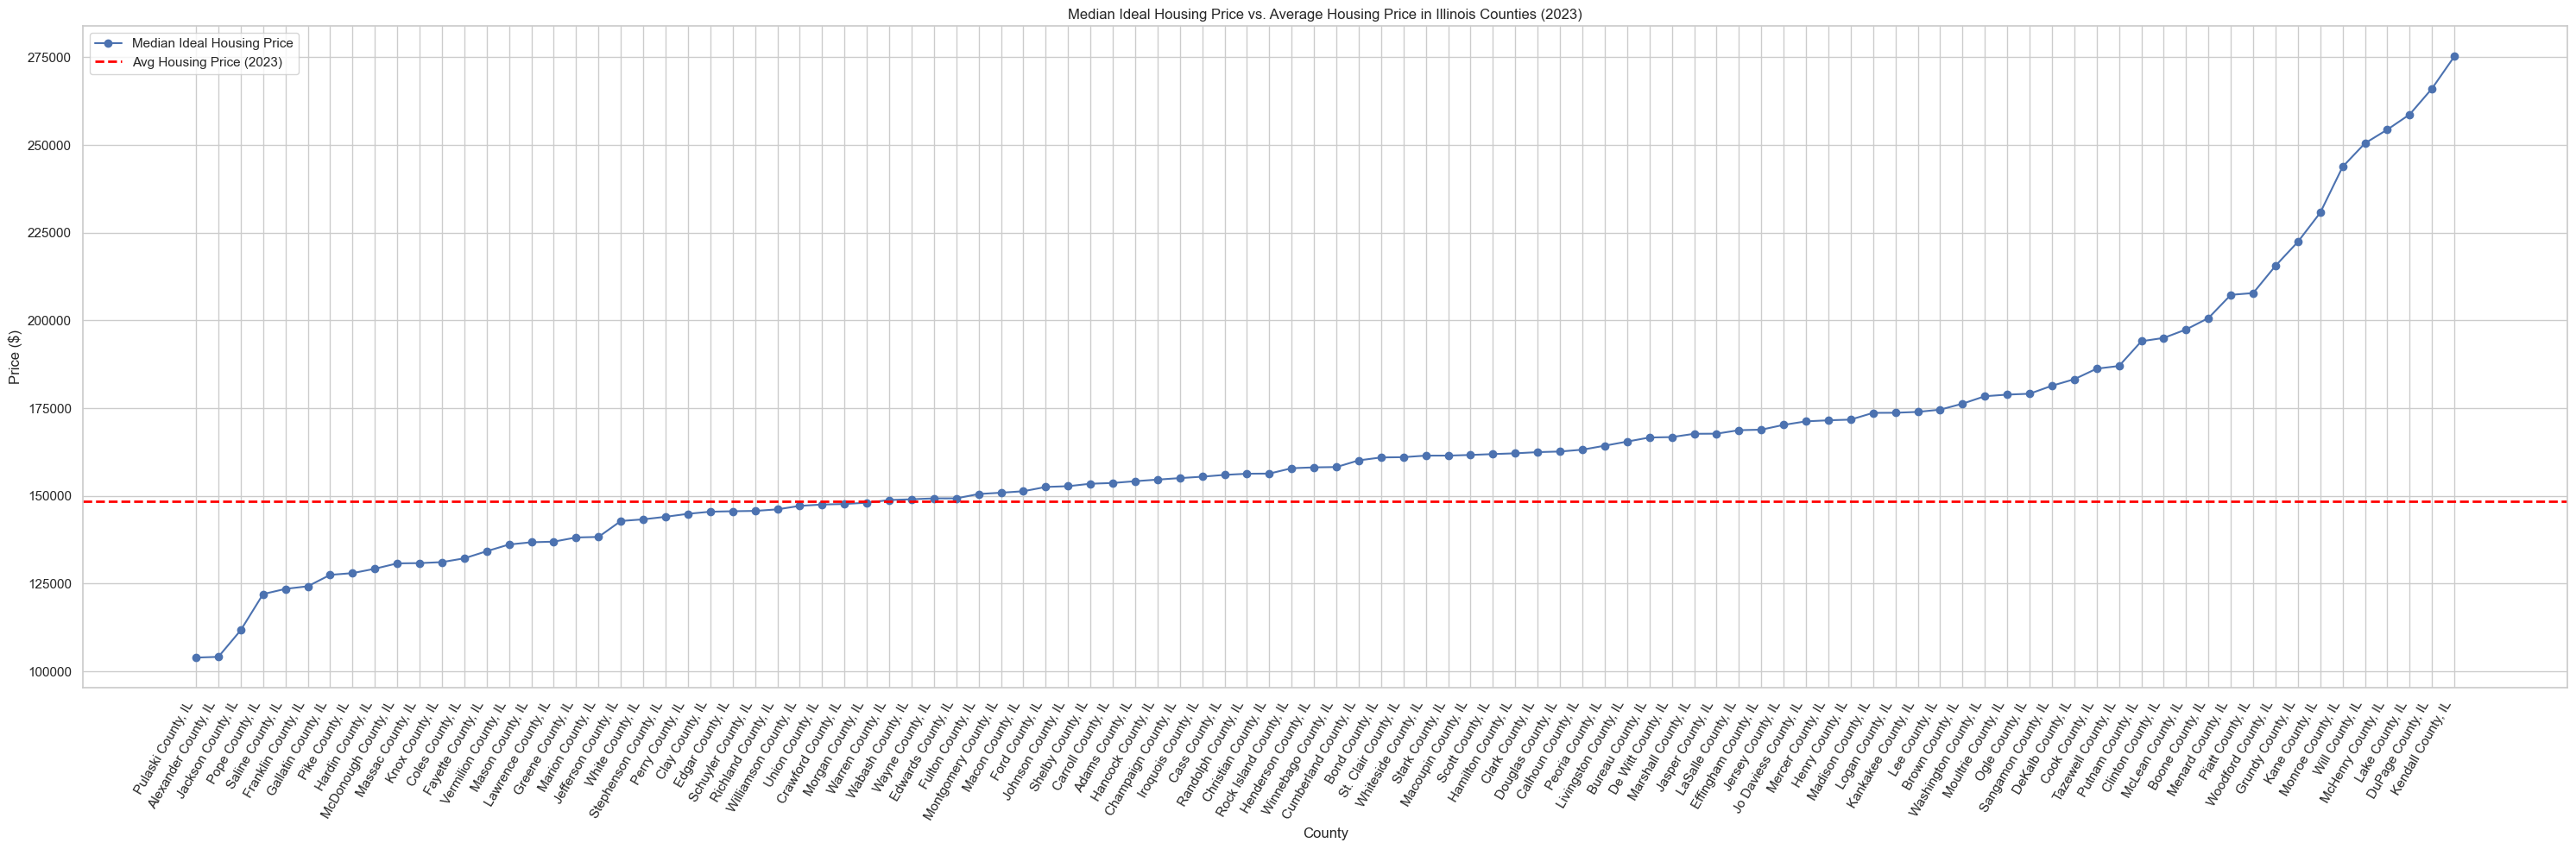

In [18]:
graph = all_functions.county_graph()
graph.show()

#### **Reality Check: How Far County-level Home Prices Drift from What’s Ideal**
This line chart compares average housing prices of each county of Illinois during 2023 and ideal housing price using the 3X annual income rule. The red dashed line represents the income-based affordability threshold, while the blue line shows the real housing market conditions across counties. What stands out is that in most counties, especially toward the right side of the chart, actual home prices far exceed what would be considered affordable based on local income levels. This gap highlights a growing affordability crisis, where even relatively high incomes in certain areas are not enough to keep up with surging housing costs. Focusing on Illinois as for our anaylsis we noticed that looking at a county level may be an important factor when considering home buying.

After observing that affordability varies across location, question arises: **Even if you find an affordable location, does ***when*** you buy also impact affordability?**

### **Visualization 3 : Monthly Home Price Deviations from the Yearly Average**
**Hypothesis 3:** Some months of the year are more affordable than others for buying a home.

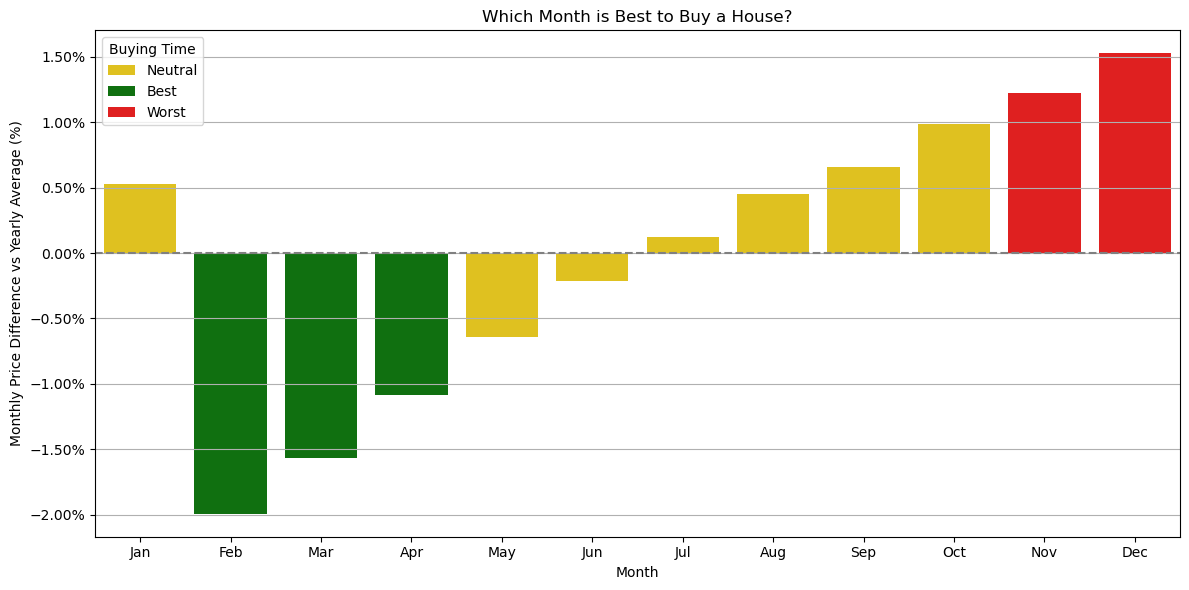

In [5]:
all_functions.visual3()

#### **Which Month Is Best to Buy a Home?**
This chart analyzes how monthly home prices deviate from the yearly average, helping identify the best and worst times of year to purchase a home. Months are categorized as Best, Neutral, or Worst based on how far their average price falls below or rises above the yearly mean. The data shows that February, March, and April consistently offer better deals, with prices falling below the annual average. In contrast, November and December tend to be the most expensive months to buy a home. This suggests that timing your purchase strategically particularly in the early part of the year can lead to meaningful savings, even in high cost markets.

Knowing *when* to buy can help—but the bigger question is: **which states are actually affordable to begin with?**

## **4. Machine Learning analysis**

### **ML Model 1: K-Means Clustering**
Since there were no labeled outcomes or predefined affordability categories in the data, we chose unsupervised learning, specifically K-Means clustering, to let the data reveal natural groupings. To capture both current and long-term affordability trends, we used the following four features per state: Median Home Value in 2023, Home Value Growth Rate (2000–2023), Median Income in 2023, Income Growth Rate (2000–2023)

In [20]:
state_yearly_df = all_functions.homevalues_dataset(home_values)

In [21]:
income = pd.read_csv('median_income.csv')
income = all_functions.income_dataset_ML(income)

homevalues_dataset() and income_dataset_ML() function prepares the homevalues and income data to feed into the clustering algorithm. clustering() function is doing all the above mentioned processing and returning a dataframe for clustering. All features of the dataframe are normalized using standard scaling to ensure equal weighting in the clustering algorithm.

In [22]:
clustering_df = all_functions.clustering(state_yearly_df, income)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_df)

### Choosing the value of K
To determine the optimal number of clusters (K), we used the Elbow Method and Silhouette Score. We created a functtion called baseline() which dates the dataset and the range of K values we want to test as input and plots the intertia and silhouette score as output. We gave the range of K values as 2 to 10. The elbow plot showed diminishing returns after K=3, and although the silhouette score peaked at K=2, the interpretability of K=3 (high, moderate, and low affordability) aligned better with the real-world context of the problem. Therefore, **K=3** was selected.

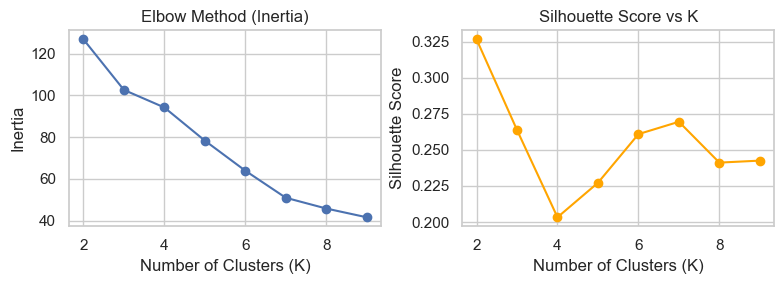

In [34]:
all_functions.baseline(scaled_data,2,10)

### Baseline
To make sure our clustering actually found meaningful patterns, we compared it to a random baseline. Our model had a much higher silhouette score, confirming that the grouping wasn’t random.

In [24]:
clustering_df = all_functions.ML1_predict(clustering_df, scaled_data)

Silhouette Score (Random Clustering): -0.045
Silhouette Score (K-Means Clustering): 0.264


### Results & Interpretation
The clustering grouped states into three affordability tiers. States like Texas, Iowa, and Mississippi were clustered as high affordability, while California, Hawaii were identified as low affordability. Some states formed a moderate affordability group. These clusters are visualized on a U.S. map using color-coded choropleth shading, clearly showing regional patterns in affordability.<br>
Note: if unable to see here a public link from plotly studio of our visualizationhttps://chart-studio.plotly.com/~eeaguilar02/6/

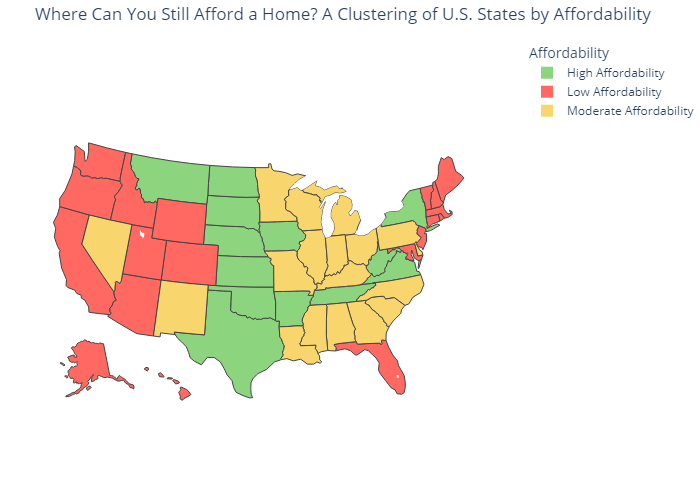

In [25]:
all_functions.showClustersInMap(clustering_df)

#### **Where Can You Still Afford a Home? A Clustering of U.S. States by Affordability**
This map shows the results of a K-Means clustering analysis that grouped U.S. states into three categories based on housing affordability: high, moderate, or low affordability based on the relationship between rising home prices and income levels. High Affordable states tend to have relatively low home values and/or healthy income growth, making it easier for residents to afford homes. Many of these are in the central and mountain regions, such as Montana, Texas, and Maine. Moderate Affordabile states fall somewhere in the middle. This group includes a mix of Midwestern and Southern states like Tennessee, Michigan, and Pennsylvania. Low Affordabile states are where home prices have significantly outpaced income growth, making housing much harder to afford. These include coastal states like California, Florida, which are known for high cost-of-living pressures. The map visually confirms a growing affordability divide in the U.S., with coastal and southern states generally showing lower affordability, while some interior and less densely populated states remain more accessible for homebuyers.

Now that we’ve grouped states by affordability, the next step is to ask: What factors actually drive these differences in home values? **Can we predict home values based on income and growth trends across states?**

### **ML 2: Linear Regression**
To explore the impact of income on housing prices, we built a linear regression model to predict 2023 median home values using state-level income, income growth, and home value growth. After testing multiple models — including Ridge, Lasso, Random Forest, and Gradient Boosting — linear regression delivered the best performance, balancing accuracy and interpretability. As a baseline, we used a naive model that predicts the mean home value for all states. The baseline performed poorly (R² = -0.157, RMSE = 240,871), while our regression model achieved a much stronger fit (R² = 0.680, RMSE = 126,663).

Baseline R²: -0.157
Baseline RMSE: $240,871.43
Linear Regression Model R² Score: 0.680
Linear Regression Model RMSE: $126,663.02


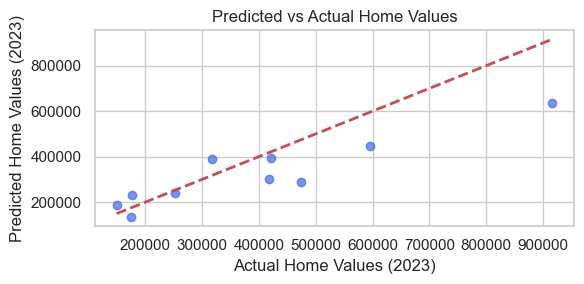

In [26]:
all_functions.Regression(clustering_df)

#### **Income Matters, But It’s Not Enough to Predict Home Values**
This visualization presents the relationship between predicted and actual 2023 home values using a linear regression model based on income, income growth, and home value growth. The model achieves a moderate R² score, indicating that these economic indicators do explain a meaningful portion of housing price variation across states. However, the noticeable spread of points around the ideal prediction line highlights a key insight: **income and growth alone are not sufficient to fully predict home values.**

This gap between predicted and actual values suggests that housing markets are influenced by a wider range of factors that go beyond basic economic capacity. In other words, while income clearly matters, it’s not the only variable at play — and understanding affordability requires looking beyond just financial indicators.

**Future Work:** This analysis shows that income alone cannot fully explain home value differences, suggesting that future work should explore additional factors—such as population density, housing supply, job accessibility, and regional amenities—to better understand what truly drives home prices across states.

## **5. Conclusion:**
This project explored the widening gap between income and home prices across the U.S. from 2000 to 2023. Through visualizations, clustering, and regression analysis, we found that rising income does not necessarily translate to increased housing affordability. Affordability varies significantly by time and location, and cannot be explained by income alone. These findings are especially relevant to policymakers, urban planners, and prospective homebuyers seeking to understand the complex dynamics behind today’s housing market. This report provides data-driven insights that can support more informed decisions around housing policy and affordability strategies.

Link to the Jupyter Notebook file: https://github.com/uic-cs418/group-project-stat-squad/blob/main/FinalReport.ipynb <br>
Link to the all_functions file: https://github.com/uic-cs418/group-project-stat-squad/blob/main/all_functions.py